### Implement the preprocessing and justify the preprocessing steps

In [1]:
# --- 1. Import required libraries ---
import re
import string
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK resources if you haven't already
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')


import spacy
nlp = spacy.load("en_core_web_sm")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam, AdamW, RMSprop

import joblib



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
df = pd.read_csv('CyberBullying Comments Dataset.csv')

In [3]:
# Initialize reusable objects
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Function to expand simple contractions
def expand_contractions(text):
    contractions = {
        "can't": "cannot", "won't": "will not", "ain't": "is not", "don't": "do not",
        "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
        "'t": " not", "'ve": " have", "'m": " am"
    }
    for c, expanded in contractions.items():
        text = re.sub(c, expanded, text)
    return text

# Function to clean text
def clean_text(text):
    # 0. Ensure it's a string
    text = str(text)

    # 1. Lowercase
    text = text.lower()

    # 2. Replace URLs and mentions
    text = re.sub(r'http\S+|www\S+|https\S+', ' URL ', text)
    text = re.sub(r'@\w+', ' USER ', text)
    text = re.sub(r'#', '', text)  # remove hashtag symbol, keep word

    # Handle LITERAL escape sequences FIRST (before removing punctuation)
    text = text.replace('\\n', ' ')   # literal \n (two chars)
    text = text.replace('\\r', ' ')   # literal \r (two chars)
    text = text.replace('\\t', ' ')   # literal \t (two chars)

    # Handle ACTUAL escape characters
    text = text.replace('\n', ' ')    # actual newline
    text = text.replace('\r', ' ')    # actual carriage return
    text = text.replace('\t', ' ')    # actual tab
    text = text.replace('\xa0', ' ')  # actual non-breaking space

    # 3. Remove special hidden characters
    text = text.replace('xa0', ' ')   # non-breaking space (do this FIRST)
    # Remove \xc2 AFTER dealing with \xa0
    text = text.replace('xc2', '')

    # 4. Expand contractions
    text = expand_contractions(text)

    # 5. Remove numbers and punctuation (keep ! and ? optionally)
    text = re.sub(r'[0-9]+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation.replace('!', '').replace('?', '')))

    # 6. Normalize repeated characters (e.g., sooooo → sooo)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 7. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Tokenization, stopword removal, and lemmatization

def preprocess_spacy(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop]
    return ' '.join(tokens)

def preprocess_text(text):
    text = clean_text(text)
    text = preprocess_spacy(text)
    return text

In [4]:
# Apply preprocessing
df['clean_text'] = df['Text'].apply(preprocess_text)

print(df[['Text', 'clean_text', 'CB_Label']])

                                                    Text  \
0      damn there is someones nana up here at beach w...   
1      no kidding! dick clark was a corpse mechanical...   
2      i read an article on jobros and thought damn w...   
3      I got one fucking day of sprinkles and now it'...   
4      I was already listening to Elliott smith  and ...   
...                                                  ...   
11095  "Don't worry you little empty head over it ......   
11096  "Some of Ya'll are dumb as fuck.... These are ...   
11097  "Lana, you're so full of shit your eyes are br...   
11098  "You ain't lying let the @dbeeio61:disqus\xa0\...   
11099  "Looks like that little Cut-n-paste job has go...   

                                              clean_text  CB_Label  
0      damn someone nana beach not think ic steal qui...         0  
1      kidding ! dick clark corpse mechanically opera...         0  
2      read article jobros think damn cash jobro poke...         0  
3  

### Extract features and justify the methods used

### Select features and justify the methods used

In [5]:
# Shuffle the dataset randomly before splitting
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['CB_Label'],
    test_size=0.15,
    stratify=df['CB_Label'],
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1111,  # makes final 75/10/15 split
    stratify=y_train,
    random_state=42
)


tfidf = TfidfVectorizer(
    max_features=10000,      # increase from 20k → 40k (try 50k if memory allows)
    ngram_range=(1, 2),      # include trigrams to capture insults or phrases ("you are stupid")               # ignore words appearing in fewer than 3 docs (reduces noise)
)

X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_val_tfidf   = tfidf.transform(X_val).toarray()
X_test_tfidf  = tfidf.transform(X_test).toarray()

# Optional scaling (can slightly help dense layers)
scaler = StandardScaler(with_mean=False)
X_train_tfidf = scaler.fit_transform(X_train_tfidf)
X_val_tfidf   = scaler.transform(X_val_tfidf)
X_test_tfidf  = scaler.transform(X_test_tfidf)



In [6]:


input_dim = X_train_tfidf.shape[1]

model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(1024, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

optimizer = AdamW(learning_rate=5e-4, weight_decay=1e-4)
# Alternative:
# optimizer = RMSprop(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc')]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │    10,241,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,837,761 (41.34 MB)

 Trainable params: 10,834,689 (41.33 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [7]:
callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=2, mode='max', min_lr=1e-6, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, mode='max', restore_best_weights=True)
]


history = model.fit(
    X_train_tfidf, y_train,
    validation_data=(X_val_tfidf, y_val),
    epochs=40,               # was 10–20, now can go up to 30–40
    batch_size=128,          # larger batches often generalize better on GPUs
    callbacks=callbacks,
    verbose=1
)




Epoch 1/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 11s 83ms/step - auc: 0.5242 - loss: 0.9060 - val_auc: 0.6425 - val_loss: 0.7187 - learning_rate: 5.0000e-04
Epoch 2/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.8359 - loss: 0.4997 - val_auc: 0.7053 - val_loss: 0.7505 - learning_rate: 5.0000e-04
Epoch 3/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - auc: 0.9651 - loss: 0.2440 - val_auc: 0.6875 - val_loss: 0.9950 - learning_rate: 5.0000e-04
Epoch 4/40
63/66 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - auc: 0.9889 - loss: 0.1390
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc: 0.9889 - loss: 0.1392 - val_auc: 0.6846 - val_loss: 1.1951 - learning_rate: 5.0000e-04
Epoch 5/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - auc: 0.9943 - loss: 0.0980 - val_auc: 0.6892 - val_loss: 1.2430 - learning_rate: 2.5000e-04
Epoch 6/40
60/66 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.9974 - loss: 0.0706
Epoch 6: ReduceLROnPlateau reducing learning rate 

In [8]:
y_pred_proba = model.predict(X_test_tfidf).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
              precision    recall  f1-score   support

           0       0.70      0.61      0.65       833
           1       0.65      0.73      0.69       832

    accuracy                           0.67      1665
   macro avg       0.67      0.67      0.67      1665
weighted avg       0.67      0.67      0.67      1665

[[505 328]
 [221 611]]


In [9]:
model.save("cyberbullying_nn.keras")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [10]:
modelT = keras.models.load_model("cyberbullying_nn.keras")
tfidf = joblib.load("tfidf_vectorizer.pkl")
scaler = joblib.load("scaler.pkl")

In [11]:
dfB = pd.read_csv("cyberbullying_tweets.csv", header=None)
dfB.columns = ['tweet_text', 'cyberbullying_type']

dfB['cyberbullying_type'] = dfB['cyberbullying_type'].apply(lambda x: 0 if x == 'not_cyberbullying' else 1)

print(dfB['cyberbullying_type'].unique())     # should print [0 1]
print(dfB['cyberbullying_type'].value_counts())


[1 0]
cyberbullying_type
1    39748
0     7945
Name: count, dtype: int64


In [12]:
dfB['clean_text'] = dfB['tweet_text'].apply(clean_text)

# Shuffle the dataset randomly before splitting
dfB = dfB.sample(frac=1, random_state=42).reset_index(drop=True)

XB = dfB['clean_text']
yB = dfB['cyberbullying_type']

In [13]:
# 3) Split into train/validation/test (stratified)
XB_train, XB_temp, yB_train, yB_temp = train_test_split(
    XB, yB, test_size=0.2, random_state=42, stratify=yB
)
XB_val, XB_test, yB_val, yB_test = train_test_split(
    XB_temp, yB_temp, test_size=0.5, random_state=42, stratify=yB_temp
)
print(f"Train size: {len(XB_train)}, Val size: {len(XB_val)}, Test size: {len(XB_test)}")

Train size: 38154, Val size: 4769, Test size: 4770


In [14]:
XB_train_tfidf = tfidf.transform(XB_train)
XB_val_tfidf = tfidf.transform(XB_val)
XB_test_tfidf = tfidf.transform(XB_test)


XB_train_tfidf = scaler.transform(XB_train_tfidf)
XB_val_tfidf   = scaler.transform(XB_val_tfidf)
XB_test_tfidf  = scaler.transform(XB_test_tfidf)

In [15]:
# 5) Freeze all but the final layer for transfer learning
for layer in model.layers[:-2]:
    layer.trainable = False

modelT.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-4),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc')]
)

# 6) Fine-tune on the train split, validate on val split
history = modelT.fit(
    XB_train_tfidf, yB_train,
    epochs=40,
    #class_weight='balanced',
    batch_size=64,
    validation_data=(X_val_tfidf, y_val),
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_auc', patience=3, restore_best_weights=True)
    ],
    verbose=1
)


Epoch 1/40
597/597 ━━━━━━━━━━━━━━━━━━━━ 512s 850ms/step - auc: 0.7573 - loss: 0.4649 - val_auc: 0.6412 - val_loss: 0.6909
Epoch 2/40
597/597 ━━━━━━━━━━━━━━━━━━━━ 100s 169ms/step - auc: 0.8972 - loss: 0.2793 - val_auc: 0.6378 - val_loss: 0.7848
Epoch 3/40
597/597 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - auc: 0.9282 - loss: 0.2390 - val_auc: 0.6380 - val_loss: 0.9006
Epoch 4/40
597/597 ━━━━━━━━━━━━━━━━━━━━ 47s 78ms/step - auc: 0.9443 - loss: 0.2145 - val_auc: 0.6413 - val_loss: 1.0745
Epoch 5/40
597/597 ━━━━━━━━━━━━━━━━━━━━ 55s 92ms/step - auc: 0.9531 - loss: 0.1950 - val_auc: 0.6211 - val_loss: 1.3466
Epoch 6/40
597/597 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - auc: 0.9634 - loss: 0.1725 - val_auc: 0.6124 - val_loss: 1.3660
Epoch 7/40
597/597 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - auc: 0.9668 - loss: 0.1658 - val_auc: 0.6081 - val_loss: 1.5837


In [16]:

# 7) Evaluate on the held-out test split & print confusion matrix + report
test_metrics = modelT.evaluate(XB_test_tfidf, yB_test, verbose=0)
print(f"Test AUC: {test_metrics[1]:.4f}")

# Predict probabilities, then apply 0.5 threshold (adjustable)
yB_pred_proba = model.predict(XB_test_tfidf).ravel()
yB_pred = (yB_pred_proba >= 0.5).astype(int)

print("\nClassification Report (Test):")
print(classification_report(yB_test, yB_pred, digits=4))

cm = confusion_matrix(yB_test, yB_pred)
print("Confusion Matrix (counts):")
print(cm)

Test AUC: 0.8585
150/150 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.2412    0.4767    0.3204       795
           1     0.8700    0.7001    0.7759      3975

    accuracy                         0.6629      4770
   macro avg     0.5556    0.5884    0.5481      4770
weighted avg     0.7652    0.6629    0.6999      4770

Confusion Matrix (counts):
[[ 379  416]
 [1192 2783]]


Text(0.5, 1.0, 'Predicted probabilities')

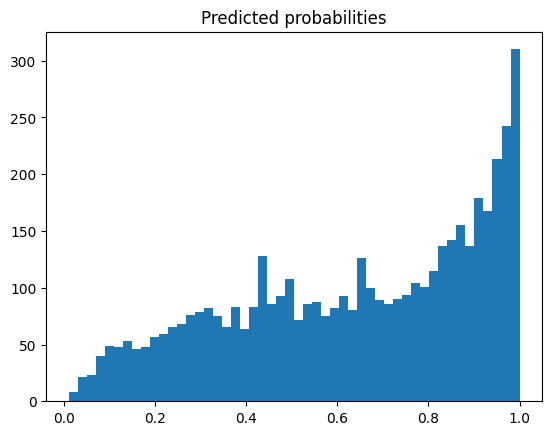

In [17]:

import matplotlib.pyplot as plt
plt.hist(yB_pred_proba, bins=50)
plt.title("Predicted probabilities")


In [18]:
print(yB_pred_proba[:20])

[0.62902975 0.47178176 0.27213657 0.68576527 0.19710958 0.41469893
 0.65597147 0.2198333  0.9715498  0.43983772 0.05872003 0.72453696
 0.27568975 0.27230918 0.98325545 0.9379426  0.9646012  0.4560687
 0.5604144  0.66109174]
